# 00 — Exploración del dataset Black Basta

Inspección del fichero `blackbasta_chats.json`:  
formato, estadísticas básicas, actores, canales y distribución temporal.

## 0. Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('src').resolve()))

import re
import pandas as pd
import matplotlib.pyplot as plt
from loaders import load_blackbasta

RAW_FILE = Path('/home/drjekyll/Documentos/umbrella/data_bruto/Ransomware/BlackBasta-Chats-main/blackbasta_chats.json')
assert RAW_FILE.exists(), f'No se encuentra {RAW_FILE}'

print(f'Tamaño fichero: {RAW_FILE.stat().st_size / 1024**2:.1f} MB')

Tamaño fichero: 47.6 MB


## 1. Inspección del formato raw

In [2]:
with open(RAW_FILE, encoding='utf-8', errors='replace') as f:
    content = f.read()

print('=== Primeros 600 caracteres ===')
print(content[:600])
print()
print(f'Tamaño total: {len(content):,} caracteres')
print(f'Objetos {{}} detectados: {content.count(chr(10) + "{"):,}')

=== Primeros 600 caracteres ===
{
    timestamp: 2023-09-18 13:35:07,
    chat_id: !VdvDXHFZwWDpIAtpCj:matrix.bestflowers247.online,
    sender_alias: @usernamenn:matrix.bestflowers247.online,
    message: BAZA
}
{
    timestamp: 2023-09-18 13:50:31,
    chat_id: !uJZKZVgGmmSiNvobZH:matrix.bestflowers247.online,
    sender_alias: @usernamess:matrix.bestflowers247.online,
    message: !!!
}
{
    timestamp: 2023-09-18 17:43:18,
    chat_id: !FtoGkSqUPiGjGNKkOl:matrix.bestflowers247.online,
    sender_alias: @usernameyy:matrix.bestflowers247.online,
    message: cpu 2core 2.4 ghz, 4 gb ram, 100 gb space x2
}
{
    timestamp: 2

Tamaño total: 46,056,190 caracteres
Objetos {} detectados: 195,964


In [3]:
# Ejemplo de mensaje multilínea
idx = content.find('```')
if idx > 0:
    start = content.rfind('{', 0, idx)
    end   = content.find('}', idx) + 1
    print('=== Ejemplo de mensaje multilínea ===')
    print(content[start:end])

=== Ejemplo de mensaje multilínea ===
{
    timestamp: 2023-09-18 17:44:42,
    chat_id: !FtoGkSqUPiGjGNKkOl:matrix.bestflowers247.online,
    sender_alias: @usernameyy:matrix.bestflowers247.online,
    message: ```
Login: usernameboy
Password: wet4vEtZq!D2sCRFdV!TRXwq3Tx!XC2ZzScX4vZQ

Login: username777
Password: FgTTe@fCSSC%qaFBTb43RXFVA1farXq!3Zc35wRT

Login: usernamehunter
Password: v1vAq24gV!45zB!xt!dxqAg4@ESaa!re4xDtr#v%

```
matrix.bestflowers247.online
}


## 2. Carga con el loader custom

In [4]:
df = load_blackbasta(RAW_FILE)

print('=== DATASET BLACK BASTA ===')
print(f'  Mensajes totales : {len(df):,}')
print(f'  Actores únicos   : {df.username.nunique()}')
print(f'  Canales únicos   : {df.channel.nunique()}')
print(f'  Rango temporal   : {df.timestamp.min().date()} → {df.timestamp.max().date()}')
print(f'  NaT timestamps   : {df.timestamp.isna().sum()}')
print()
display(df.head(5))

=== DATASET BLACK BASTA ===
  Mensajes totales : 195,407
  Actores únicos   : 49
  Canales únicos   : 79
  Rango temporal   : 2023-09-18 → 2024-09-28
  NaT timestamps   : 0



,timestamp,username,channel,message,source
0,2023-09-18 13:35:07+00:00,usernamenn,VdvDXHFZwWDpIAtpCj,BAZA,blackbasta
1,2023-09-18 13:50:31+00:00,usernamess,uJZKZVgGmmSiNvobZH,!!!,blackbasta
2,2023-09-18 17:43:18+00:00,usernameyy,FtoGkSqUPiGjGNKkOl,"cpu 2core 2.4 ghz, 4 gb ram, 100 gb space x2",blackbasta
3,2023-09-18 17:44:42+00:00,usernameyy,FtoGkSqUPiGjGNKkOl,```\nLogin: usernameboy\nPassword: wet4vEtZq!D...,blackbasta
4,2023-09-18 17:47:48+00:00,usernameyy,kJVcUcyUsQhwBCuIPD,1,blackbasta


## 3. Actores

In [5]:
actor_counts = df.groupby('username').size().sort_values(ascending=False)
print('Mensajes por actor:')
print(actor_counts.to_string())

Mensajes por actor:
username
usernamegg            83072
lapa                  26258
w                     13439
usernamenn             8509
usernameyy             7172
n3auxaxl               6386
usernameugway          6076
usernamess             5504
nickolas               3670
cameron777             3641
muaddib6               2454
ssd                    2281
burito                 2169
usernameww             1694
cob_crypt_ward         1678
usernamevv             1641
lincoln                1640
usernamemm             1609
usernamezz             1534
usernamett             1516
usernamecc             1417
chuck                  1374
tinker                 1163
mel                    1106
usernamejj              914
u123                    783
iamnurnazarov           734
usernamexx              698
usernameboy             659
manager361              577
usernamehunter          516
manager880              481
username777             471
usernameff              395
arslanshabbirmalik 

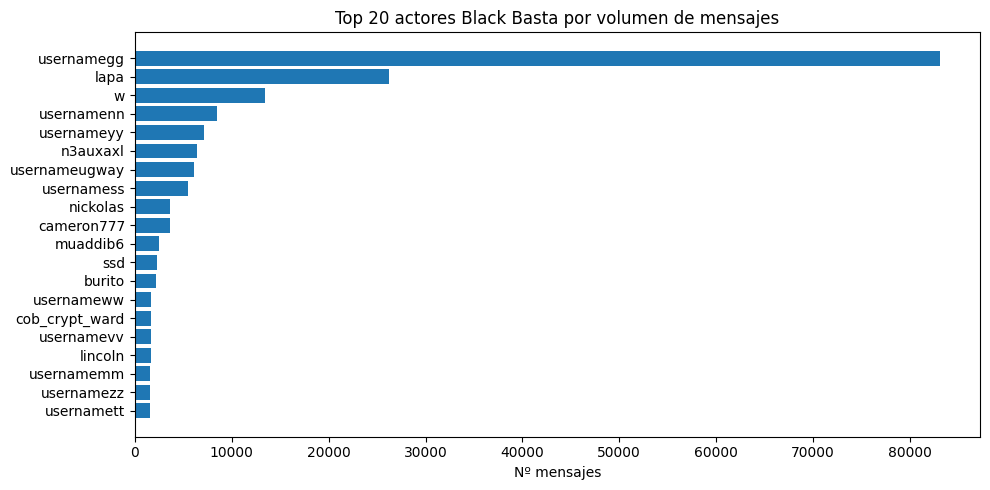

In [6]:
top_n = 20
top_actors = actor_counts.head(top_n)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_actors.index[::-1], top_actors.values[::-1])
ax.set_title(f'Top {top_n} actores Black Basta por volumen de mensajes')
ax.set_xlabel('Nº mensajes')
plt.tight_layout()
plt.show()

## 4. Canales

In [7]:
channel_counts = df.groupby('channel').size().sort_values(ascending=False)
print(f'Top 20 canales por actividad:')
print(channel_counts.head(20).to_string())

Top 20 canales por actividad:
channel
nPsXVNwvPnfPbfsDcD    48933
BHEZrXZjNIsCKJMUYJ    20375
kJVcUcyUsQhwBCuIPD    13938
BOpqkyiMnBRfCPXwod    12470
RVxOPEuHMjKrYEQOpn    11180
LZIbnhnZMcQWZqmgzs     9997
SwOPmpPcbXMKVYoYrQ     9628
HOwizKpRWUvwqLnQAt     7264
EWFYRyuNbrMKmhIlzZ     4646
RMdGGuCKLBreGJPwlH     4216
MNovtbJOsRikjXSEYE     4162
movQbFbGmaZTcobDtK     3556
SrYuQddDovXeEsAmBh     3306
BJxdVvCxirwdeMdIiw     3062
HWdiqTZMSjlcPLzxjy     3035
FJNepzdTumLjULNYKA     2970
dqgXlehEZabQITeRcg     2842
sUYHRwQnrbjklKmEfq     2769
AMKxwPhkMPYAfABhRo     2372
CzaymkzesDwGIctmLA     2346


## 5. Actividad temporal

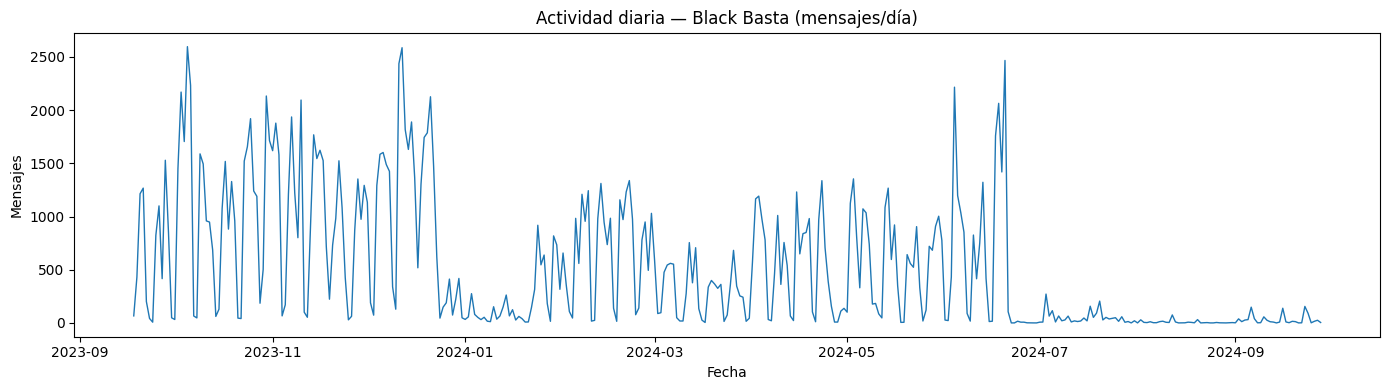


Pico máximo: 2023-10-05  (2,597 msgs)
Media diaria: 518 msgs/día


In [8]:
daily = df.set_index('timestamp').resample('D').size()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily.values, linewidth=1)
ax.set_title('Actividad diaria — Black Basta (mensajes/día)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Mensajes')
plt.tight_layout()
plt.show()

print(f'\nPico máximo: {daily.idxmax().date()}  ({daily.max():,} msgs)')
print(f'Media diaria: {daily.mean():.0f} msgs/día')

## 6. Longitud de mensajes

count    195407.0
mean         58.7
std         360.9
min           1.0
25%          10.0
50%          21.0
75%          41.0
max       22161.0

Mensajes < 5 chars  : 22,986
Mensajes > 500 chars: 2,110


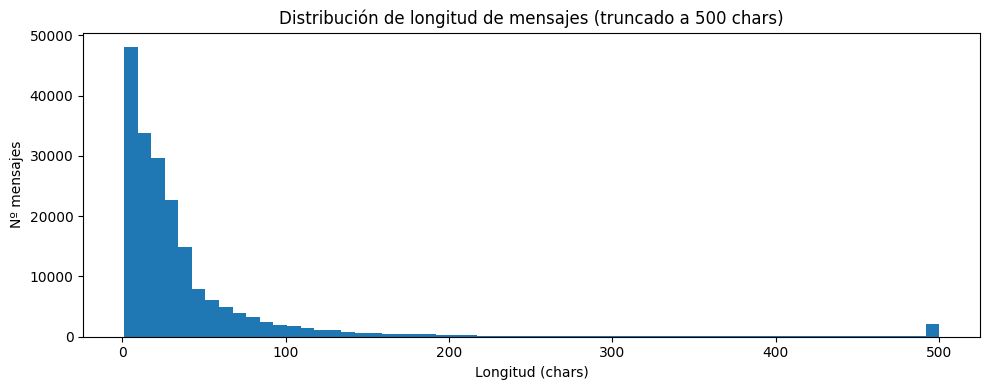

In [9]:
df['msg_len'] = df['message'].str.len()

print(df['msg_len'].describe().round(1).to_string())
print(f'\nMensajes < 5 chars  : {(df.msg_len < 5).sum():,}')
print(f'Mensajes > 500 chars: {(df.msg_len > 500).sum():,}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['msg_len'].clip(upper=500), bins=60, edgecolor='none')
ax.set_title('Distribución de longitud de mensajes (truncado a 500 chars)')
ax.set_xlabel('Longitud (chars)')
ax.set_ylabel('Nº mensajes')
plt.tight_layout()
plt.show()